# Validate an interval at one chosen input

Fix **$x_*=0.5$**. We want a range for the next response at this input.

A Bayesian model will propose the range. **Only fresh measurements and a
concentration bound will support its actual coverage.** The experiment below
deliberately uses a wrong linear model.

## 1. Separate the sensor from the model

The actual sensor is nonlinear:

$$Y=1+2x+2x^2+\varepsilon,\qquad\varepsilon\sim\mathcal N(0,0.5^2).$$

Our working model still assumes a straight line, Gaussian coefficient prior
$\mathbf w\sim\mathcal N(0,4I)$, and Gaussian noise of standard deviation 0.5.
There is no coefficient pair that makes this line model equal to the true
mean curve. We use its calculations to propose an interval, without assuming
its model or prior describes reality.

All observations here are simulated. In an application, the validation
measurements must come from the actual system.


In [1]:
import math
from statistics import NormalDist
import numpy as np
import matplotlib.pyplot as plt

QUERY = 0.5              # fix the input before validation
TEST_COUNT = 10_000       # fix the measurement count too
FAILURE_CHANCE = 0.05

train_rng, validation_rng = [
    np.random.default_rng(s)
    for s in np.random.SeedSequence(20260919).spawn(2)
]

def actual_mean(x):
    return 1 + 2*x + 2*x*x

x_train = train_rng.uniform(-1, 1, 20)
y_train = actual_mean(x_train) + train_rng.normal(0, 0.5, 20)


## 2. Propose an interval at this input

Use the same Gaussian Bayesian regression calculation as in Bishop.
Each row of $\Phi$ is $[1,x_i]$. The following code computes the working
model's posterior mean and covariance, then its predictive interval at
$0.5$.

Its nominal 99% level is a setting in this calculation, **not a real-world
coverage guarantee**.
[Proposal calculation reference](https://www.microsoft.com/en-us/research/wp-content/uploads/2016/05/prml-slides-3.pdf).


In [2]:
alpha, beta = 0.25, 4.0
Phi = np.column_stack([np.ones(len(x_train)), x_train])
precision = alpha*np.eye(2) + beta*Phi.T@Phi
S = np.linalg.solve(precision, np.eye(2))
m = np.linalg.solve(precision, beta*Phi.T@y_train)

phi = np.array([1.0, QUERY])
center = float(phi@m)
proposal_sd = math.sqrt(1/beta + phi@S@phi)
z = NormalDist().inv_cdf(0.995)
low, high = center-z*proposal_sd, center+z*proposal_sd
print(f"At x = {QUERY}, the proposed interval is [{low:.3f}, {high:.3f}]")


At x = 0.5, the proposed interval is [1.516, 4.196]


The candidate is **[1.516, 4.196]**. Freeze it now.

## 3. Repeat the measurement at exactly the same input

Obtain 10,000 independent responses at **$x=0.5$**, and count how many land
inside the candidate. These are new responses from the sensor, not samples
from the fitted Bayesian model.


In [3]:
validation_y = actual_mean(QUERY) + validation_rng.normal(0, 0.5, TEST_COUNT)
inside = (validation_y >= low) & (validation_y <= high)
hits = int(inside.sum())
observed_coverage = hits / TEST_COUNT
print(f"At x = {QUERY}: {hits:,} of {TEST_COUNT:,} responses inside")
print(f"Measured conditional coverage: {100*observed_coverage:.2f}%")


At x = 0.5: 9,745 of 10,000 responses inside
Measured conditional coverage: 97.45%


**9,745 of 10,000** are inside: **97.45% measured coverage at this input**.

## 4. Put a rigorous lower bound on that coverage

Let $p_*$ be the actual probability that a new response at $x=0.5$ falls
inside the frozen interval. Every validation response supplies an independent
0-or-1 observation with mean $p_*$.

The one-sided Hoeffding bound gives a 95% lower confidence bound:

$$
p_*\ \geq\ \widehat p_*-
\sqrt{\frac{\log(1/0.05)}{2N}}.
$$

The allowance is **1.224 percentage points**, leaving **96.226%**.
Rounding downward, report:

> At input x = 0.5, with 95% confidence, the fixed interval [1.516, 4.196]
> covers at least **96.2% of future responses at this input**.

Endpoint values in this sentence are displayed rounded; the calculation
uses their full precision.


In [4]:
allowance = math.sqrt(math.log(1/FAILURE_CHANCE) / (2*TEST_COUNT))
lower_bound = max(0, observed_coverage-allowance)
reported_percent = math.floor(1000*lower_bound) / 10
print(f"Hoeffding allowance: {100*allowance:.3f} percentage points")
print(f"At x = {QUERY}, coverage is at least {reported_percent:.1f}% "
      "with 95% confidence.")


Hoeffding allowance: 1.224 percentage points
At x = 0.5, coverage is at least 96.2% with 95% confidence.


The 95% confidence concerns the validation experiment: the chance this
procedure overstates $p_*$ is at most 5%. The 96.2% concerns future responses
at the chosen input. **Neither the linear model nor the Gaussian prior needs
to be correct for this statement.**
[Hoeffding reference](https://www.cs.rpi.edu/academics/courses/spring06/random/hoefding.pdf).

## 5. Plot only what was tested

The histogram shows repeated responses at $x=0.5$. The two dashed lines
mark the proposed endpoints. There is no band across untested input values.


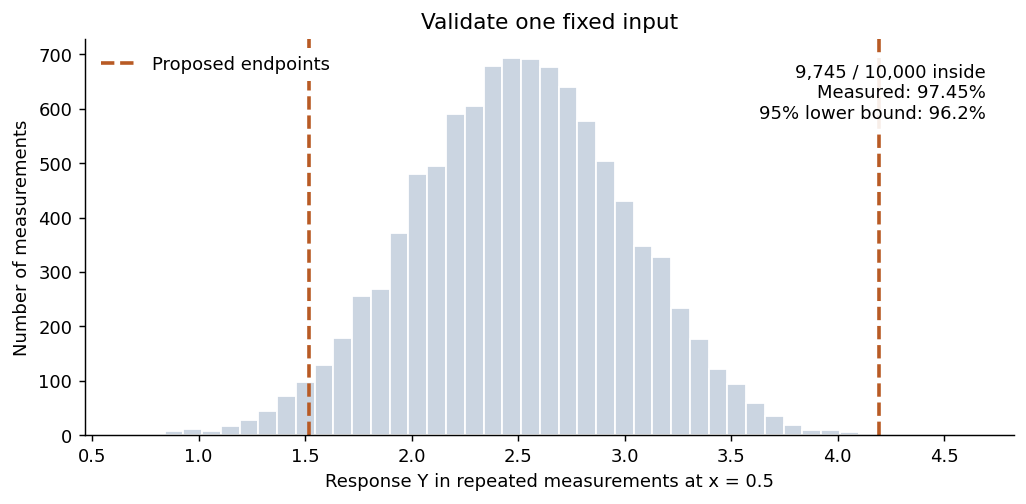

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(validation_y, bins=45, color="#cbd5e1", edgecolor="white")
ax.axvline(low, color="#b85a24", ls="--", lw=2, label="Proposed endpoints")
ax.axvline(high, color="#b85a24", ls="--", lw=2)
ax.set(xlabel=f"Response Y in repeated measurements at x = {QUERY}",
       ylabel="Number of measurements", title="Validate one fixed input")
ax.text(0.97, 0.94,
        f"{hits:,} / {TEST_COUNT:,} inside\n"
        f"Measured: {100*observed_coverage:.2f}%\n"
        f"95% lower bound: {reported_percent:.1f}%",
        transform=ax.transAxes, ha="right", va="top", fontsize=10,
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.9})
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=True, facecolor="white", edgecolor="none", framealpha=1,
          loc="upper left")
fig.tight_layout()
plt.show()


**Scope:** this statement certifies one chosen input and interval. At another
input, run a corresponding conditional experiment. Separate 95% statements
are not a simultaneous 95% guarantee across inputs.

**Required access:** you need independent measurements at the chosen input,
or valid access to its true conditional distribution. A generic test set
with randomly located continuous inputs does not provide this guarantee at
an exact new input without additional structure. A simulator certifies only
the process it faithfully represents.

More measurements reduce the statistical allowance. They do not repair a
poor proposed interval. If you revise the interval after checking it, validate
the revision on fresh responses.
